# Amplitude Estimation — spiegazione passo per passo

**Obiettivo:** capire in modo semplice l'algoritmo di **Amplitude Estimation (AE)**:
cosa stima, perché è più efficiente del Monte Carlo classico, e cosa sono gli operatori **$A$** e **$Q$**.

**Percorso del notebook**
1. Il problema: stimare una probabilità
2. Approccio classico (Monte Carlo) e i suoi limiti
3. Traduzione quantistica: l'ampiezza $\sqrt{a}$
4. Operatore **$A$** (preparazione dello stato)
5. Operatore **$Q$** (rotazione / amplificazione)
6. Come AE estrae $a$ dalla fase
7. Confronto classico vs quantistico (vantaggio quadratico)
8. Mini-simulazione numerica + circuito Qiskit (opzionale)

**Prerequisiti:** `.venv-quantum` attivo (`pip install -r quantum/requirements.txt`).

## 0. Setup

In [1]:
import sys
from pathlib import Path

try:
    sys.stdout.reconfigure(encoding="utf-8")
except (AttributeError, ValueError):
    pass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyBboxPatch
from IPython.display import display

%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.28,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

rng = np.random.default_rng(42)

# Qiskit è opzionale: il notebook resta utile anche solo con numpy/matplotlib
try:
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator
    from qiskit.circuit.library import GroverOperator
    from qiskit.quantum_info import Statevector
    HAS_QISKIT = True
except ImportError:
    HAS_QISKIT = False

print(f"Ready. Qiskit disponibile: {HAS_QISKIT}")

Ready. Qiskit disponibile: True


## 1. Il problema in una frase

Vuoi stimare una **probabilità sconosciuta** $a \in [0,1]$.

Esempi concreti:
- probabilità che una moneta (possibilmente truccata) esca testa;
- frazione di punti sotto una curva (integrazione Monte Carlo);
- probabilità di un evento raro in finanza, fisica, ML…

Nel linguaggio quantistico, $a$ è spesso l'**ampiezza al quadrato** di uno stato "buono":

$$|\psi\rangle = A|0\rangle = \sqrt{1-a}\,|\text{bad}\rangle + \sqrt{a}\,|\text{good}\rangle$$

Quindi **Amplitude Estimation** = stimare $a$ (o $\sqrt{a}$) misurando in modo intelligente lo stato preparato da $A$.

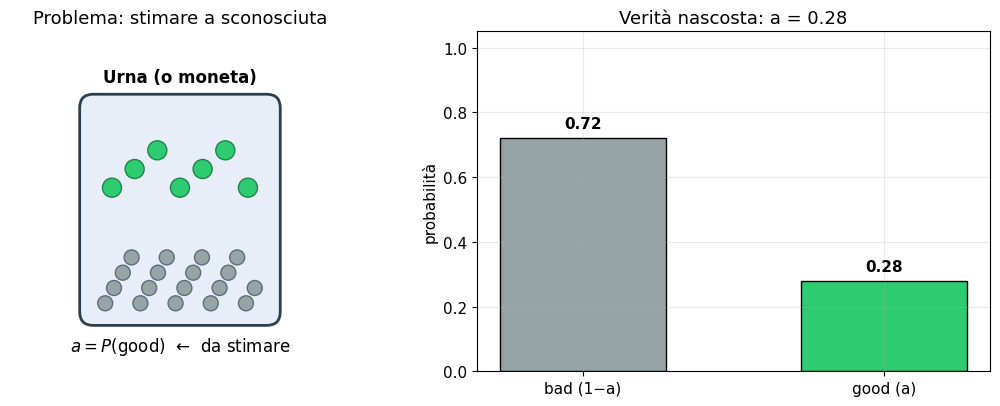

In [2]:
# --- Visuale: il problema come "urna" / moneta truccata ---
a_true = 0.28  # probabilità sconosciuta da stimare (la "verità")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Urna
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Problema: stimare a sconosciuta")

urn = FancyBboxPatch((2.2, 1.5), 5.6, 6.5, boxstyle="round,pad=0.15,rounding_size=0.4",
                     facecolor="#e8eef7", edgecolor="#2c3e50", linewidth=2)
ax.add_patch(urn)
ax.text(5, 8.5, "Urna (o moneta)", ha="center", fontsize=12, fontweight="bold")

# palline proporzionali ad a
n_good, n_bad = 7, 18
xs_g = np.linspace(3.0, 7.0, n_good)
ys_g = 3.2 + 0.55 * (np.arange(n_good) % 3)
for x, y in zip(xs_g, ys_g):
    ax.add_patch(Circle((x, y + 2.2), 0.28, color="#2ecc71", ec="#1e8449", lw=1))
xs_b = np.linspace(2.8, 7.2, n_bad)
ys_b = 2.0 + 0.45 * (np.arange(n_bad) % 4)
for x, y in zip(xs_b, ys_b):
    ax.add_patch(Circle((x, y), 0.22, color="#95a5a6", ec="#5d6d7e", lw=1))

ax.text(5, 0.6, r"$a = P(\mathrm{good})$  ←  da stimare", ha="center", fontsize=12)

# Barra probabilità
ax = axes[1]
ax.bar(["bad (1−a)", "good (a)"], [1 - a_true, a_true],
       color=["#95a5a6", "#2ecc71"], edgecolor="black", width=0.55)
ax.set_ylim(0, 1.05)
ax.set_ylabel("probabilità")
ax.set_title(f"Verità nascosta: a = {a_true:.2f}")
for i, v in enumerate([1 - a_true, a_true]):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 2. Approccio classico: Monte Carlo

Idea banale ma potente:
1. estrai $N$ campioni indipendenti (lanci della moneta / estrazioni dall'urna);
2. conta quante volte esce "good";
3. stima $\hat{a} = \frac{\#\text{ good}}{N}$.

Per la legge dei grandi numeri / teorema del limite centrale, l'errore tipico scala come:

$$\varepsilon_{\text{classico}} \sim \frac{1}{\sqrt{N}} \qquad\Rightarrow\qquad N \sim \frac{1}{\varepsilon^2}$$

Per dimezzare l'errore ti servono **4 volte** più campioni. È il costo "quadratico" del Monte Carlo classico.

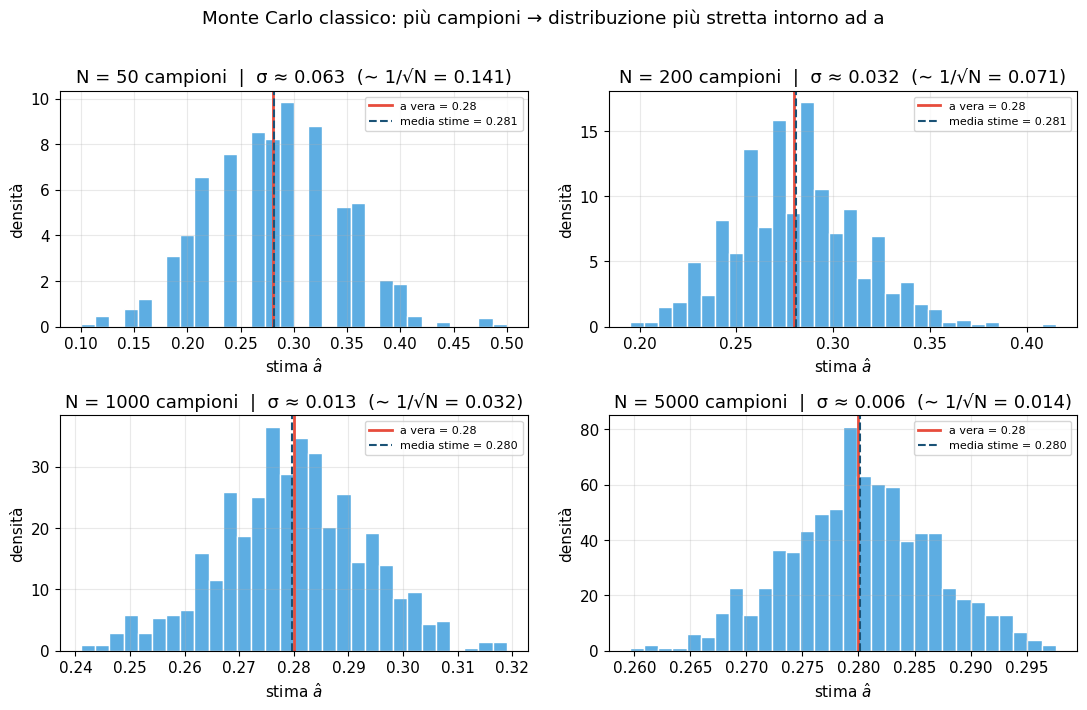

In [3]:
def classical_estimate(a, N, rng):
    """Stima Monte Carlo di a con N campioni Bernoulli."""
    samples = rng.random(N) < a
    return samples.mean()


# Molte ripetizioni per vedere la distribuzione della stima
Ns = [50, 200, 1000, 5000]
n_trials = 800

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=False)
axes = axes.ravel()

for ax, N in zip(axes, Ns):
    estimates = np.array([classical_estimate(a_true, N, rng) for _ in range(n_trials)])
    std = estimates.std()
    ax.hist(estimates, bins=30, color="#5dade2", edgecolor="white", density=True)
    ax.axvline(a_true, color="#e74c3c", lw=2, label=f"a vera = {a_true}")
    ax.axvline(estimates.mean(), color="#1a5276", ls="--", lw=1.5,
               label=f"media stime = {estimates.mean():.3f}")
    ax.set_title(f"N = {N} campioni  |  σ ≈ {std:.3f}  (∼ 1/√N = {1/np.sqrt(N):.3f})")
    ax.set_xlabel(r"stima $\hat{a}$")
    ax.set_ylabel("densità")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Monte Carlo classico: più campioni → distribuzione più stretta intorno ad a", y=1.01)
plt.tight_layout()
plt.show()

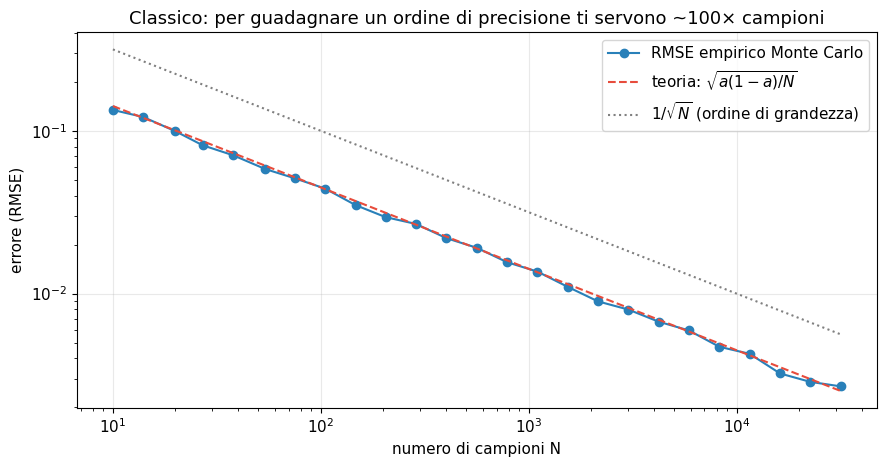

In [4]:
# --- Scaling dell'errore classico ---
N_grid = np.unique(np.round(np.logspace(1, 4.5, 25)).astype(int))
rmse = []
for N in N_grid:
    est = np.array([classical_estimate(a_true, N, rng) for _ in range(400)])
    rmse.append(np.sqrt(np.mean((est - a_true) ** 2)))
rmse = np.array(rmse)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.loglog(N_grid, rmse, "o-", color="#2980b9", label="RMSE empirico Monte Carlo")
ax.loglog(N_grid, np.sqrt(a_true * (1 - a_true) / N_grid), "--", color="#e74c3c",
          label=r"teoria: $\sqrt{a(1-a)/N}$")
ax.loglog(N_grid, 1 / np.sqrt(N_grid), ":", color="gray", label=r"$1/\sqrt{N}$ (ordine di grandezza)")
ax.set_xlabel("numero di campioni N")
ax.set_ylabel("errore (RMSE)")
ax.set_title("Classico: per guadagnare un ordine di precisione ti servono ~100× campioni")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Passaggio al mondo quantistico

Invece di campionare bit classici, prepariamo uno **stato quantistico** la cui ampiezza "good" è $\sqrt{a}$:

$$|\psi\rangle = \sqrt{1-a}\,|0\rangle + \sqrt{a}\,|1\rangle$$

(Qui usiamo 1 qubit per semplicità: $|0\rangle$ = bad, $|1\rangle$ = good.)

Un trucco geometrico importantissimo: introduciamo un angolo $\theta$ tale che

$$a = \sin^2\theta \qquad\Rightarrow\qquad \theta = \arcsin\sqrt{a}$$

Allora

$$|\psi\rangle = \cos\theta\,|0\rangle + \sin\theta\,|1\rangle$$

**Idea chiave di AE:** se riusciamo a stimare bene $\theta$, otteniamo $a = \sin^2\theta$.
E c'è un operatore $Q$ che **ruota** questo angolo di $2\theta$ a ogni applicazione — come un orologio che avanza a passi fissi.

a = 0.2800
θ = arcsin(√a) = 0.5576 rad  (31.95°)
sin²(θ) = 0.2800  (recupera a)


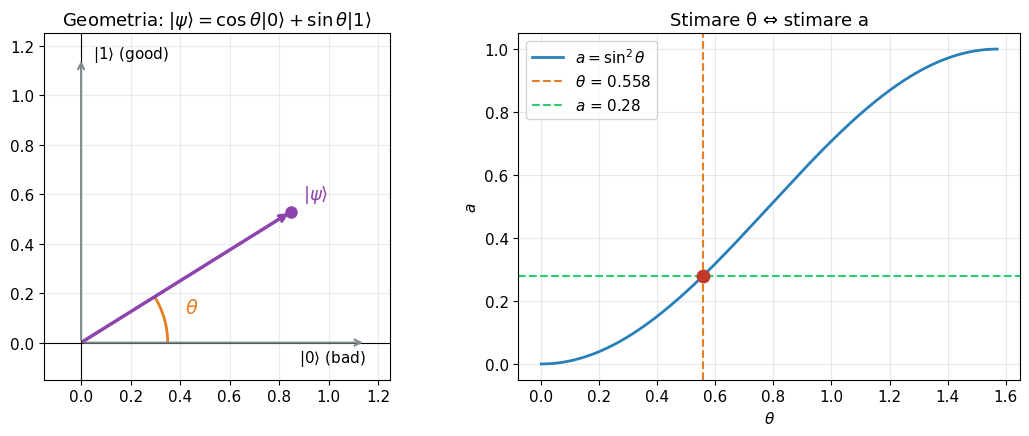

In [5]:
theta = np.arcsin(np.sqrt(a_true))
print(f"a = {a_true:.4f}")
print(f"θ = arcsin(√a) = {theta:.4f} rad  ({np.degrees(theta):.2f}°)")
print(f"sin²(θ) = {np.sin(theta)**2:.4f}  (recupera a)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Piano |0>–|1>
ax = axes[0]
ax.set_aspect("equal")
ax.set_xlim(-0.15, 1.25)
ax.set_ylim(-0.15, 1.25)
ax.axhline(0, color="k", lw=0.8)
ax.axvline(0, color="k", lw=0.8)
ax.annotate("", xy=(1.15, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="#7f8c8d", lw=1.5))
ax.annotate("", xy=(0, 1.15), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="#7f8c8d", lw=1.5))
ax.text(1.15, -0.08, r"$|0\rangle$ (bad)", ha="right")
ax.text(0.05, 1.15, r"$|1\rangle$ (good)")

x, y = np.cos(theta), np.sin(theta)
ax.annotate("", xy=(x, y), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="#8e44ad", lw=2.5))
ax.plot(x, y, "o", color="#8e44ad", ms=8)
ax.add_patch(Arc((0, 0), 0.7, 0.7, theta1=0, theta2=np.degrees(theta),
                 color="#e67e22", lw=2))
ax.text(0.42, 0.12, r"$\theta$", color="#e67e22", fontsize=14)
ax.text(x + 0.05, y + 0.05, r"$|\psi\rangle$", color="#8e44ad", fontsize=13)
ax.set_title(r"Geometria: $|\psi\rangle = \cos\theta|0\rangle + \sin\theta|1\rangle$")
ax.grid(True, alpha=0.25)

# Curva a = sin^2(theta)
ax = axes[1]
th = np.linspace(0, np.pi / 2, 300)
ax.plot(th, np.sin(th) ** 2, color="#2980b9", lw=2, label=r"$a=\sin^2\theta$")
ax.axvline(theta, color="#e67e22", ls="--", label=rf"$\theta$ = {theta:.3f}")
ax.axhline(a_true, color="#2ecc71", ls="--", label=rf"$a$ = {a_true:.2f}")
ax.plot(theta, a_true, "o", color="#c0392b", ms=9)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$a$")
ax.set_title("Stimare θ ⇔ stimare a")
ax.legend()

plt.tight_layout()
plt.show()

## 4. Operatore $A$ — la "fabbrica" dello stato

L'operatore **$A$** (state-preparation / amplitude-encoding) è un circuit unitario che prepara lo stato con l'ampiezza desiderata:

$$A|0\rangle = |\psi\rangle = \sqrt{1-a}\,|\text{bad}\rangle + \sqrt{a}\,|\text{good}\rangle$$

### Cosa rappresenta in pratica?
- un circuito che calcola una funzione e marca i risultati "buoni";
- un oracolo di Monte Carlo quantistico (pricing, integrazione, …);
- nel caso più semplice: una rotazione $R_y(2\theta)$ su un qubit, perché

$$R_y(2\theta)|0\rangle = \cos\theta|0\rangle + \sin\theta|1\rangle$$

**In AE non serve conoscere $a$ a priori:** $A$ è una "scatola nera" che sai costruire (il tuo modello / oracolo), ma di cui non conosci l'ampiezza di uscita — ed è proprio quella che vuoi stimare.

Matrice A = Ry(2θ):
[[ 0.8485+0.j -0.5292+0.j]
 [ 0.5292+0.j  0.8485+0.j]]

Stato |ψ> = A|0>:
  ampiezza |0> (bad):  +0.8485   →  P(bad)  = 0.7200
  ampiezza |1> (good): +0.5292   →  P(good) = 0.2800 = a


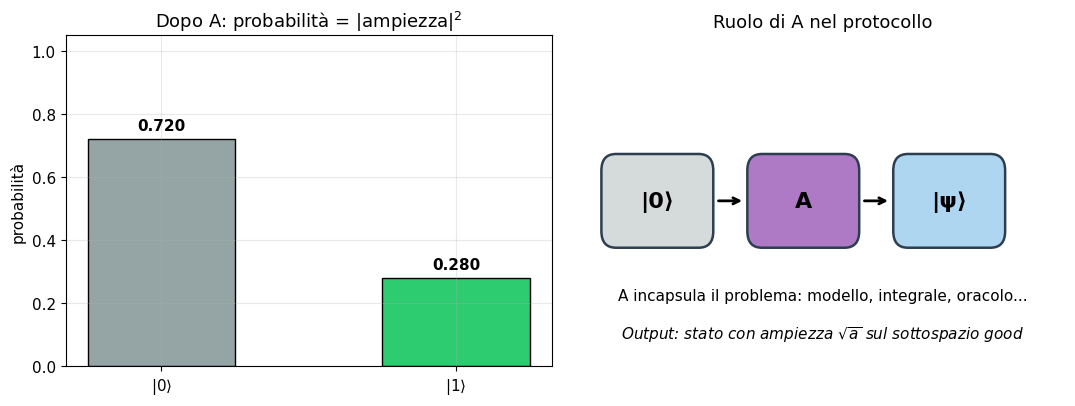

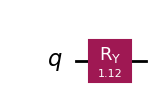

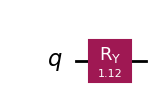

In [6]:
def operator_A(theta):
    """Matrice 2x2 di A = Ry(2θ): prepara cosθ|0> + sinθ|1>."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]], dtype=complex)


A = operator_A(theta)
psi = A @ np.array([1, 0], dtype=complex)

print("Matrice A = Ry(2θ):")
print(np.round(A, 4))
print("\nStato |ψ> = A|0>:")
print(f"  ampiezza |0> (bad):  {psi[0].real:+.4f}   →  P(bad)  = {abs(psi[0])**2:.4f}")
print(f"  ampiezza |1> (good): {psi[1].real:+.4f}   →  P(good) = {abs(psi[1])**2:.4f} = a")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.bar([r"$|0\rangle$", r"$|1\rangle$"], np.abs(psi) ** 2,
       color=["#95a5a6", "#2ecc71"], edgecolor="black", width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("probabilità")
ax.set_title(r"Dopo A: probabilità = $|\mathrm{ampiezza}|^2$")
for i, p in enumerate(np.abs(psi) ** 2):
    ax.text(i, p + 0.03, f"{p:.3f}", ha="center", fontweight="bold")

ax = axes[1]
ax.axis("off")
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_title("Ruolo di A nel protocollo")
# boxes
for (x, txt, col) in [(0.5, "|0⟩", "#d5dbdb"), (3.5, "A", "#af7ac5"), (6.5, "|ψ⟩", "#aed6f1")]:
    ax.add_patch(FancyBboxPatch((x, 2.2), 2.2, 1.6, boxstyle="round,pad=0.05,rounding_size=0.3",
                                facecolor=col, edgecolor="#2c3e50", lw=1.8))
    ax.text(x + 1.1, 3.0, txt, ha="center", va="center", fontsize=16, fontweight="bold")
ax.annotate("", xy=(3.4, 3.0), xytext=(2.8, 3.0), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(6.4, 3.0), xytext=(5.8, 3.0), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(5, 1.2, r"A incapsula il problema: modello, integrale, oracolo...",
        ha="center", fontsize=11)
ax.text(5, 0.5, r"Output: stato con ampiezza $\sqrt{a}$ sul sottospazio good",
        ha="center", fontsize=11, style="italic")

plt.tight_layout()
plt.show()

if HAS_QISKIT:
    qc_A = QuantumCircuit(1, name="A")
    qc_A.ry(2 * theta, 0)
    display(qc_A.draw(output="mpl", fold=-1))
    plt.show()

## 5. Operatore $Q$ — il "motore" che ruota di $2\theta$

L'operatore **$Q$** (anche chiamato *Grover operator* / *amplitude amplification operator*) è costruito a partire da $A$:

$$Q = A S_0 A^\dagger S_\chi$$

dove:
- $S_\chi$ = riflessione rispetto agli stati **good** (cambia segno alle ampiezze good),
- $S_0$ = riflessione rispetto allo stato iniziale $|0\rangle$ (cambia segno a tutto tranne $|0\rangle$).

### Perché è magico?
Nel piano 2D generato da $\{|\text{bad}\rangle, |\text{good}\rangle\}$, $Q$ agisce come una **rotazione di angolo $2\theta$**:

$$Q^k |\psi\rangle = \cos((2k+1)\theta)\,|\text{bad}\rangle + \sin((2k+1)\theta)\,|\text{good}\rangle$$

Quindi ogni applicazione di $Q$ **amplifica** (o fa oscillare) l'ampiezza good in modo deterministico.
Gli autovalori di $Q$ sono $e^{\pm i 2\theta}$: la fase nasconde $\theta$ — e quindi $a$.

In [7]:
def reflection_S_chi():
    """S_χ: flip di fase su |1> (good). diag(1, -1)."""
    return np.diag([1.0, -1.0]).astype(complex)


def reflection_S0():
    """S_0: flip di fase su tutto tranne |0>. diag(1, -1) nel caso 1 qubit."""
    return np.diag([1.0, -1.0]).astype(complex)


def operator_Q(A):
    """Q = A S0 A† Sχ  (forma standard Amplitude Amplification)."""
    S0 = reflection_S0()
    Sx = reflection_S_chi()
    return A @ S0 @ A.conj().T @ Sx


Q = operator_Q(A)
eigvals, eigvecs = np.linalg.eig(Q)
phases = np.angle(eigvals)

print("Matrice Q:")
print(np.round(Q, 4))
print("\nAutovalori di Q (dovrebbero essere e^{±i 2θ}):")
for lam, ph in zip(eigvals, phases):
    print(f"  λ = {lam.real:+.4f}{lam.imag:+.4f}j   fase = {ph:+.4f} rad"
          f"   → |fase|/2 = {abs(ph)/2:.4f}  (θ vera = {theta:.4f})")

# Verifica: Q è una rotazione di 2θ nel piano
Q_expected = np.array([
    [np.cos(2 * theta), -np.sin(2 * theta)],
    [np.sin(2 * theta),  np.cos(2 * theta)],
], dtype=complex)
# Attenzione: a seconda della convenzione di segno delle riflessioni,
# Q può essere rotazione di +2θ o -2θ (o equivalente a meno di fasi globali).
print("\n||Q − Rot(+2θ)|| =", np.linalg.norm(Q - Q_expected))
print("||Q − Rot(−2θ)|| =", np.linalg.norm(Q - Q_expected.T))

Matrice Q:
[[ 0.44 +0.j -0.898+0.j]
 [ 0.898+0.j  0.44 +0.j]]

Autovalori di Q (dovrebbero essere e^{±i 2θ}):
  λ = +0.4400+0.8980j   fase = +1.1152 rad   → |fase|/2 = 0.5576  (θ vera = 0.5576)
  λ = +0.4400-0.8980j   fase = -1.1152 rad   → |fase|/2 = 0.5576  (θ vera = 0.5576)

||Q − Rot(+2θ)|| = 1.5700924586837752e-16
||Q − Rot(−2θ)|| = 2.539921258622007


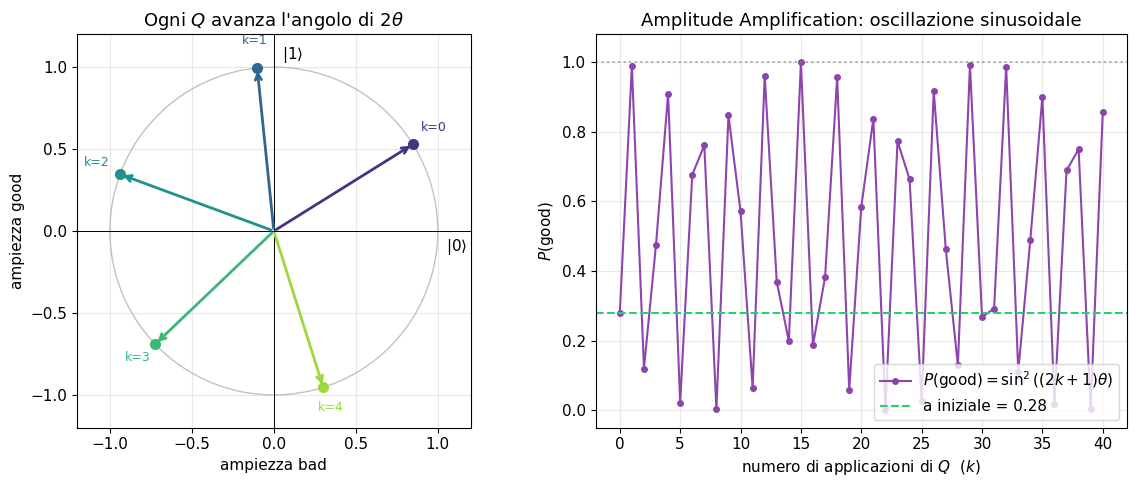

Messaggio: Q non 'indovina' a — la fa ruotare in modo che la fase 2θ diventi leggibile.


In [8]:
# --- Visuale: Q come rotazione ripetuta nel piano bad/good ---
ks = [0, 1, 2, 3, 4]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(ks)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.set_aspect("equal")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color="k", lw=0.7)
ax.axvline(0, color="k", lw=0.7)
circle = Circle((0, 0), 1, fill=False, color="#bdc3c7", lw=1)
ax.add_patch(circle)
ax.text(1.05, -0.12, r"$|0\rangle$", fontsize=11)
ax.text(0.05, 1.05, r"$|1\rangle$", fontsize=11)

state = psi.copy()
for k, col in zip(ks, colors):
    # stato dopo k applicazioni di Q a partire da |ψ> = A|0>
    # angolo teorico: (2k+1)θ
    ang = (2 * k + 1) * theta
    x, y = np.cos(ang), np.sin(ang)
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=col, lw=2))
    ax.plot(x, y, "o", color=col, ms=7)
    ax.text(1.15 * x, 1.15 * y, f"k={k}", color=col, fontsize=9, ha="center")

ax.set_title(r"Ogni $Q$ avanza l'angolo di $2\theta$")
ax.set_xlabel("ampiezza bad")
ax.set_ylabel("ampiezza good")

# Probabilità good vs k
ax = axes[1]
k_max = 40
k_arr = np.arange(0, k_max + 1)
p_good = np.sin((2 * k_arr + 1) * theta) ** 2
ax.plot(k_arr, p_good, "o-", color="#8e44ad", ms=4, label=r"$P(\mathrm{good})=\sin^2((2k+1)\theta)$")
ax.axhline(a_true, color="#2ecc71", ls="--", label=f"a iniziale = {a_true}")
ax.axhline(1.0, color="gray", ls=":", alpha=0.6)
ax.set_xlabel(r"numero di applicazioni di $Q$  ($k$)")
ax.set_ylabel(r"$P(\mathrm{good})$")
ax.set_title("Amplitude Amplification: oscillazione sinusoidale")
ax.legend(loc="lower right")
ax.set_ylim(-0.05, 1.08)

plt.tight_layout()
plt.show()

print("Messaggio: Q non 'indovina' a — la fa ruotare in modo che la fase 2θ diventi leggibile.")

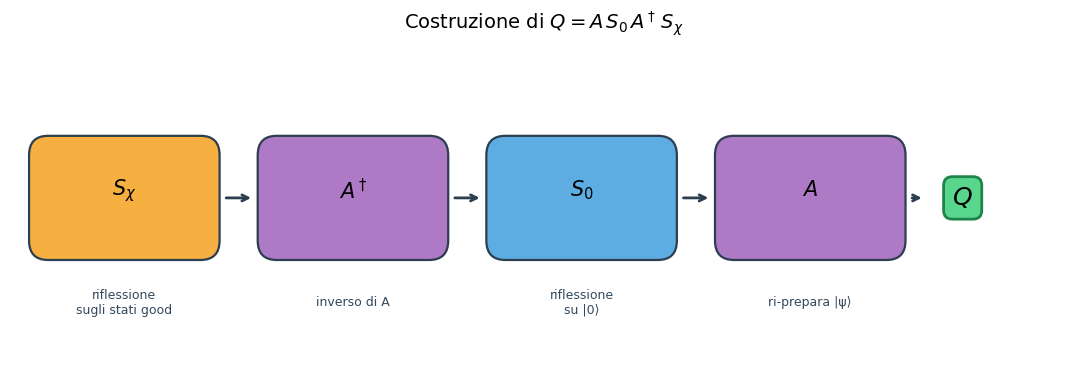

In [9]:
# --- Schema a blocchi: come si costruisce Q da A ---
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")
ax.set_title(r"Costruzione di $Q = A\, S_0\, A^\dagger\, S_\chi$", fontsize=14, pad=12)

blocks = [
    (0.3, r"$S_\chi$", "#f5b041", "riflessione\nsugli stati good"),
    (3.3, r"$A^\dagger$", "#af7ac5", "inverso di A"),
    (6.3, r"$S_0$", "#5dade2", "riflessione\nsu |0⟩"),
    (9.3, r"$A$", "#af7ac5", "ri-prepara |ψ⟩"),
]
for x, label, col, note in blocks:
    ax.add_patch(FancyBboxPatch((x, 1.3), 2.4, 1.5, boxstyle="round,pad=0.05,rounding_size=0.25",
                                facecolor=col, edgecolor="#2c3e50", lw=1.6))
    ax.text(x + 1.2, 2.15, label, ha="center", va="center", fontsize=15, fontweight="bold")
    ax.text(x + 1.2, 0.7, note, ha="center", va="center", fontsize=9, color="#34495e")

for x in [2.8, 5.8, 8.8]:
    ax.annotate("", xy=(x + 0.4, 2.05), xytext=(x, 2.05),
                arrowprops=dict(arrowstyle="->", lw=2, color="#2c3e50"))

ax.text(12.5, 2.05, r"$Q$", ha="center", va="center", fontsize=18, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#58d68d", edgecolor="#1e8449", lw=2))
ax.annotate("", xy=(12.0, 2.05), xytext=(11.8, 2.05),
            arrowprops=dict(arrowstyle="->", lw=2, color="#2c3e50"))

plt.tight_layout()
plt.show()

## 6. Come funziona Amplitude Estimation (idea)

### Versione "intuitiva"
1. Prepara $|\psi\rangle = A|0\rangle$.
2. Applica $Q$ un numero di volte controllato (Quantum Phase Estimation su $Q$).
3. Gli autovalori di $Q$ sono $e^{\pm i 2\theta}$: QPE stima la **fase** $2\theta$.
4. Ricostruisci $\hat{a} = \sin^2(\hat{\theta})$.

### Perché è meglio del classico?
Con $M$ applicazioni (queries) di $Q$ (quindi di $A$), l'errore tipico scala come

$$\varepsilon_{\text{quantistico}} \sim \frac{1}{M} \qquad\Rightarrow\qquad M \sim \frac{1}{\varepsilon}$$

contro $N \sim 1/\varepsilon^2$ del Monte Carlo. È lo **speedup quadratico**.

> Intuizione: classicamente ogni sample ti dà un bit rumoroso su $a$.
> Quantisticamente, $Q$ trasforma $a$ in una **frequenza** $2\theta$ che puoi misurare con precisione $\sim 1/M$ (come contare le tacche di un orologio più fine).

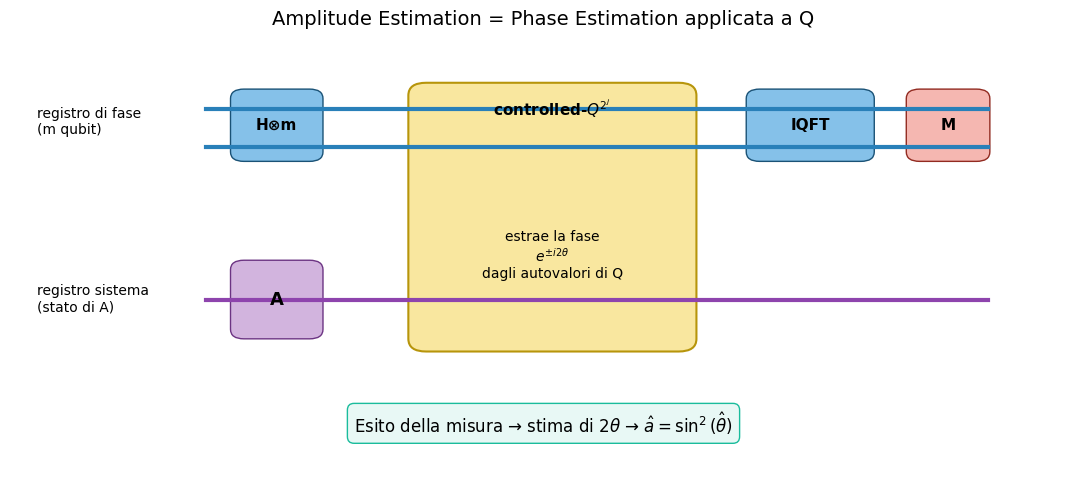

In [10]:
# --- Schema del protocollo AE (Phase Estimation su Q) ---
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")
ax.set_title("Amplitude Estimation = Phase Estimation applicata a Q", fontsize=14)

# Registri
ax.text(0.3, 5.6, "registro di fase\n(m qubit)", fontsize=10, va="center")
ax.plot([2.2, 11], [5.8, 5.8], color="#2980b9", lw=3)
ax.plot([2.2, 11], [5.2, 5.2], color="#2980b9", lw=3)

ax.text(0.3, 2.8, "registro sistema\n(stato di A)", fontsize=10, va="center")
ax.plot([2.2, 11], [2.8, 2.8], color="#8e44ad", lw=3)

# Hadamard
ax.add_patch(FancyBboxPatch((2.5, 5.0), 1.0, 1.1, boxstyle="round,pad=0.02,rounding_size=0.15",
                            facecolor="#85c1e9", edgecolor="#1a5276"))
ax.text(3.0, 5.55, "H⊗m", ha="center", va="center", fontweight="bold")

# A
ax.add_patch(FancyBboxPatch((2.5, 2.2), 1.0, 1.2, boxstyle="round,pad=0.02,rounding_size=0.15",
                            facecolor="#d2b4de", edgecolor="#6c3483"))
ax.text(3.0, 2.8, "A", ha="center", va="center", fontweight="bold", fontsize=13)

# Controlled Q^{2^j}
ax.add_patch(FancyBboxPatch((4.5, 2.0), 3.2, 4.2, boxstyle="round,pad=0.02,rounding_size=0.2",
                            facecolor="#f9e79f", edgecolor="#b7950b", lw=1.5))
ax.text(6.1, 5.7, r"controlled-$Q^{2^j}$", ha="center", fontweight="bold")
ax.text(6.1, 3.5, "estrae la fase\n$e^{±i2θ}$\ndagli autovalori di Q",
        ha="center", va="center", fontsize=10)

# IQFT
ax.add_patch(FancyBboxPatch((8.3, 5.0), 1.4, 1.1, boxstyle="round,pad=0.02,rounding_size=0.15",
                            facecolor="#85c1e9", edgecolor="#1a5276"))
ax.text(9.0, 5.55, "IQFT", ha="center", va="center", fontweight="bold")

# Measure
ax.add_patch(FancyBboxPatch((10.1, 5.0), 0.9, 1.1, boxstyle="round,pad=0.02,rounding_size=0.15",
                            facecolor="#f5b7b1", edgecolor="#922b21"))
ax.text(10.55, 5.55, "M", ha="center", va="center", fontweight="bold")

ax.text(6, 0.7,
        r"Esito della misura → stima di $2\theta$ → $\hat{a}=\sin^2(\hat{\theta})$",
        ha="center", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#e8f8f5", edgecolor="#1abc9c"))

plt.tight_layout()
plt.show()

## 7. Simulazione "toy" di AE (senza tutto il QPE)

Per capire il cuore dell'algoritmo, usiamo una versione educativa:

- sappiamo che dopo $k$ applicazioni di $Q$, $P(\mathrm{good}) = \sin^2((2k+1)\theta)$;
- scegliamo diversi $k$, stimiamo $P(\mathrm{good})$ con pochi shot;
- ricostruiamo $\theta$ (e quindi $a$) da un fit / da una griglia.

La versione completa con QPE è più potente e dà direttamente lo speedup $1/\varepsilon$,
ma questa demo rende **visibile** il legame tra $Q$, $\theta$ e $a$.

a vera     = 0.2800
a stimata  = 0.2802   (errore = 0.0002)
θ vera     = 0.5576
θ stimata  = 0.5578


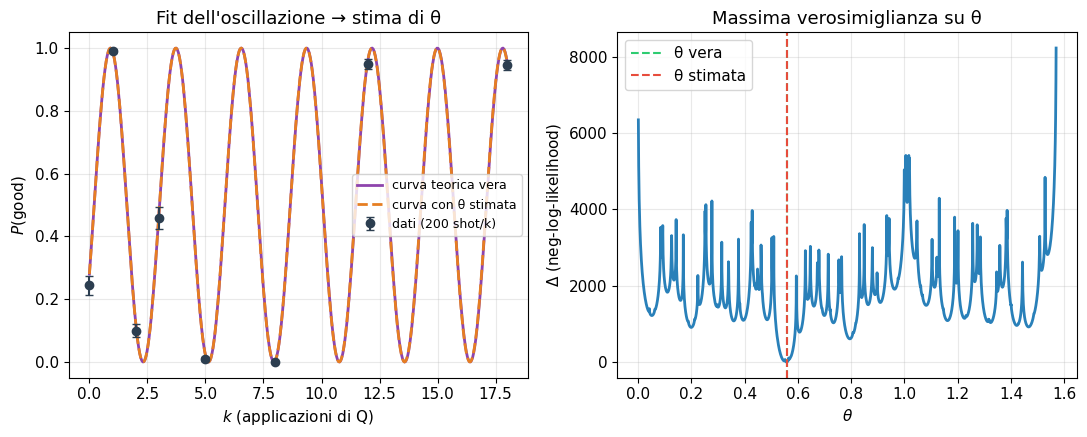

In [11]:
def measure_good_prob_after_Qk(theta, k, shots, rng):
    """Simula misure di P(good) dopo Q^k |ψ>, con shot noise Bernoulli."""
    p = np.sin((2 * k + 1) * theta) ** 2
    # clip numerico
    p = float(np.clip(p, 0.0, 1.0))
    return rng.binomial(shots, p) / shots


ks_probe = np.array([0, 1, 2, 3, 5, 8, 12, 18])
shots = 200
p_emp = np.array([measure_good_prob_after_Qk(theta, k, shots, rng) for k in ks_probe])
p_th = np.sin((2 * ks_probe + 1) * theta) ** 2

# Stima di θ con griglia (maximum likelihood grezzo)
theta_grid = np.linspace(1e-3, np.pi / 2 - 1e-3, 2500)

def neg_loglik(th):
    # likelihood Bernoulli aggregata sui vari k (approssimata)
    ps = np.sin((2 * ks_probe + 1) * th) ** 2
    ps = np.clip(ps, 1e-9, 1 - 1e-9)
    # conteggi: shots * p_emp successi
    succ = p_emp * shots
    fail = shots - succ
    return -np.sum(succ * np.log(ps) + fail * np.log(1 - ps))

nll = np.array([neg_loglik(th) for th in theta_grid])
theta_hat = theta_grid[np.argmin(nll)]
a_hat = np.sin(theta_hat) ** 2

print(f"a vera     = {a_true:.4f}")
print(f"a stimata  = {a_hat:.4f}   (errore = {abs(a_hat - a_true):.4f})")
print(f"θ vera     = {theta:.4f}")
print(f"θ stimata  = {theta_hat:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
k_fine = np.linspace(0, ks_probe.max(), 400)
ax.plot(k_fine, np.sin((2 * k_fine + 1) * theta) ** 2, color="#8e44ad", lw=2,
        label="curva teorica vera")
ax.plot(k_fine, np.sin((2 * k_fine + 1) * theta_hat) ** 2, "--", color="#e67e22", lw=2,
        label="curva con θ stimata")
ax.errorbar(ks_probe, p_emp, yerr=np.sqrt(p_emp * (1 - p_emp) / shots),
            fmt="o", color="#2c3e50", capsize=3, label=f"dati ({shots} shot/k)")
ax.set_xlabel(r"$k$ (applicazioni di Q)")
ax.set_ylabel(r"$P(\mathrm{good})$")
ax.set_title("Fit dell'oscillazione → stima di θ")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(theta_grid, nll - nll.min(), color="#2980b9", lw=2)
ax.axvline(theta, color="#2ecc71", ls="--", label="θ vera")
ax.axvline(theta_hat, color="#e74c3c", ls="--", label="θ stimata")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\Delta$ (neg-log-likelihood)")
ax.set_title("Massima verosimiglianza su θ")
ax.legend()

plt.tight_layout()
plt.show()

## 8. Confronto classico vs quantistico — il vantaggio

| | **Classico (Monte Carlo)** | **Quantistico (Amplitude Estimation)** |
|---|---|---|
| Cosa fai | campioni indipendenti | query a $A$ / potenze di $Q$ |
| Errore vs risorse | $\varepsilon \sim 1/\sqrt{N}$ | $\varepsilon \sim 1/M$ |
| Risorse per errore $\varepsilon$ | $N \sim 1/\varepsilon^2$ | $M \sim 1/\varepsilon$ |
| Speedup | — | **quadratico** |
| Quando brilla | modelli semplici, parallelismo classico | stima di probabilità / integrali costosi |

Esempio numerico: vuoi $\varepsilon = 10^{-3}$.
- classico: $\sim 10^6$ campioni;
- quantistico (ideale): $\sim 10^3$ query.

> Caveat onesti: su hardware NISQ il costo di implementare $Q$ e il rumore riducono il vantaggio.
> Il risultato è asintotico / idealizzato, ma è uno dei motivi per cui AE è centrale in **quantum finance**, **quantum ML** e **integrazione quantistica**.

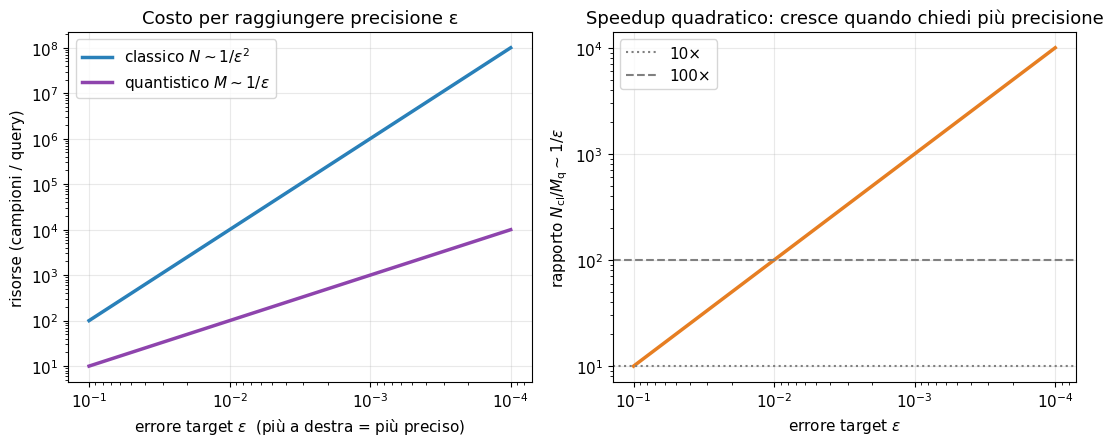

Esempi di risorse (ordini di grandezza, costanti ≈ 1):
         ε      N classico   M quantistico     speedup
     1e-01             100              10          10×
     1e-02           10000             100         100×
     1e-03         1000000            1000        1000×
     1e-04       100000000           10000       10000×


In [12]:
eps = np.logspace(-1, -4, 50)  # errori target da 0.1 a 0.0001

# Ordini di grandezza (nascondiamo costanti O(1))
N_classical = 1.0 / eps ** 2
M_quantum = 1.0 / eps

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

ax = axes[0]
ax.loglog(eps, N_classical, color="#2980b9", lw=2.5, label=r"classico $N\sim 1/\varepsilon^2$")
ax.loglog(eps, M_quantum, color="#8e44ad", lw=2.5, label=r"quantistico $M\sim 1/\varepsilon$")
ax.invert_xaxis()
ax.set_xlabel(r"errore target $\varepsilon$  (più a destra = più preciso)")
ax.set_ylabel("risorse (campioni / query)")
ax.set_title("Costo per raggiungere precisione ε")
ax.legend()

# Speedup ratio
ax = axes[1]
ax.loglog(eps, N_classical / M_quantum, color="#e67e22", lw=2.5)
ax.invert_xaxis()
ax.set_xlabel(r"errore target $\varepsilon$")
ax.set_ylabel(r"rapporto $N_{\mathrm{cl}} / M_{\mathrm{q}} \sim 1/\varepsilon$")
ax.set_title("Speedup quadratico: cresce quando chiedi più precisione")
ax.axhline(10, color="gray", ls=":", label="10×")
ax.axhline(100, color="gray", ls="--", label="100×")
ax.legend()

plt.tight_layout()
plt.show()

# Tabella numerica rapida
print("Esempi di risorse (ordini di grandezza, costanti ≈ 1):")
print(f"{'ε':>10}  {'N classico':>14}  {'M quantistico':>14}  {'speedup':>10}")
for e in [1e-1, 1e-2, 1e-3, 1e-4]:
    Nc, Mq = 1/e**2, 1/e
    print(f"{e:10.0e}  {Nc:14.0f}  {Mq:14.0f}  {Nc/Mq:10.0f}×")

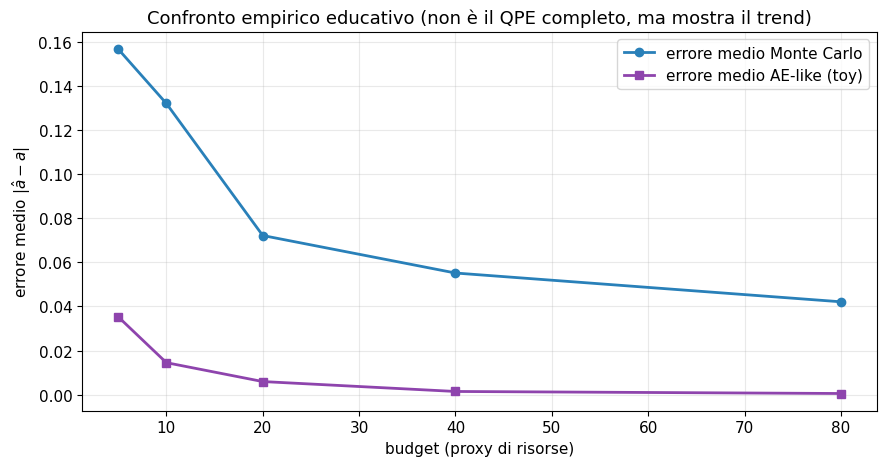

In [13]:
# --- Errore empirico: Monte Carlo vs stima 'AE-like' dal fit su Q^k ---
# Confronto educativo a budget di query crescente

def ae_like_estimate(theta_true, max_k, shots_per_k, rng):
    ks = np.arange(0, max_k + 1)
    p_emp = np.array([measure_good_prob_after_Qk(theta_true, k, shots_per_k, rng) for k in ks])
    # queries totali ≈ somma_k (2k+1) * (costo di A per Q) — semplifichiamo: usiamo max_k come proxy
    th_grid = np.linspace(1e-3, np.pi/2 - 1e-3, 1200)
    best, best_nll = None, np.inf
    for th in th_grid:
        ps = np.clip(np.sin((2 * ks + 1) * th) ** 2, 1e-9, 1 - 1e-9)
        succ = p_emp * shots_per_k
        nll = -np.sum(succ * np.log(ps) + (shots_per_k - succ) * np.log(1 - ps))
        if nll < best_nll:
            best_nll, best = nll, th
    return np.sin(best) ** 2


budgets = [5, 10, 20, 40, 80]
n_rep = 60
err_cl, err_qe = [], []

for B in budgets:
    # classico: B campioni
    cl = np.array([classical_estimate(a_true, B, rng) for _ in range(n_rep)])
    err_cl.append(np.mean(np.abs(cl - a_true)))

    # quantistico toy: max_k ~ B/4, pochi shot per k (budget grezzo)
    max_k = max(1, B // 4)
    shots_per_k = max(20, B)
    qe = np.array([ae_like_estimate(theta, max_k, shots_per_k, rng) for _ in range(n_rep)])
    err_qe.append(np.mean(np.abs(qe - a_true)))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(budgets, err_cl, "o-", color="#2980b9", lw=2, label="errore medio Monte Carlo")
ax.plot(budgets, err_qe, "s-", color="#8e44ad", lw=2, label="errore medio AE-like (toy)")
ax.set_xlabel("budget (proxy di risorse)")
ax.set_ylabel(r"errore medio $|\hat{a}-a|$")
ax.set_title("Confronto empirico educativo (non è il QPE completo, ma mostra il trend)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Mini-demo Qiskit (opzionale): $A$ e $Q$ su 1 qubit

Se Qiskit è disponibile, costruiamo $A = R_y(2\theta)$ e l'operatore di Grover $Q$,
e verifichiamo che $P(|1\rangle)$ oscilli come $\sin^2((2k+1)\theta)$.

Circuito A:


C:\Users\mabaldazzi\AppData\Local\Temp\ipykernel_10120\247005801.py:13: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  Q_op = GroverOperator(oracle, state_preparation=A_circ, insert_barriers=False)


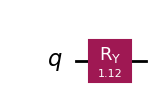

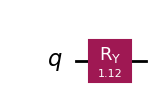

Circuito Q (GroverOperator):


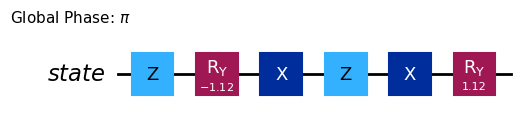

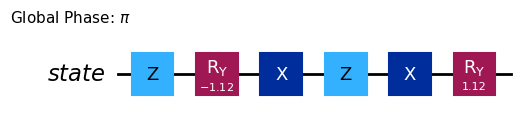

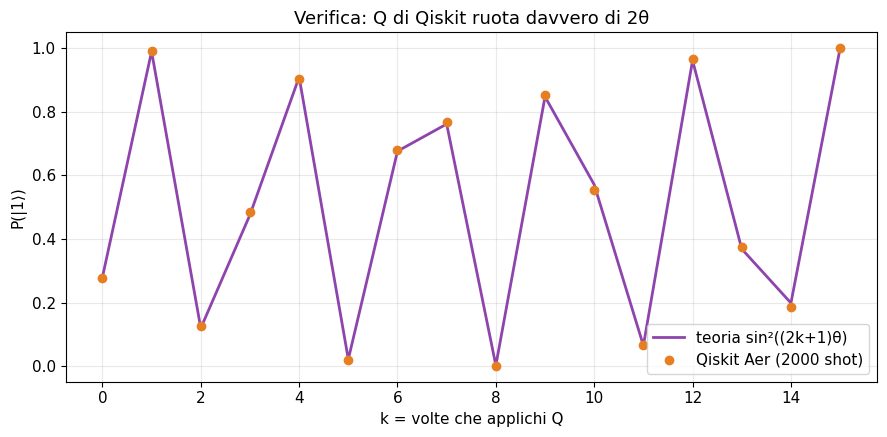

In [14]:
if not HAS_QISKIT:
    print("Qiskit non installato: salta questa sezione (il resto del notebook è già completo).")
else:
    # A: prepara lo stato
    A_circ = QuantumCircuit(1, name="A")
    A_circ.ry(2 * theta, 0)

    # Oracolo S_χ: Z su |1>  (fase -1 sul good)
    oracle = QuantumCircuit(1, name="Sχ")
    oracle.z(0)

    # GroverOperator costruisce Q a partire da A e dall'oracolo
    Q_op = GroverOperator(oracle, state_preparation=A_circ, insert_barriers=False)

    print("Circuito A:")
    display(A_circ.draw(output="mpl"))
    plt.show()

    print("Circuito Q (GroverOperator):")
    display(Q_op.decompose().draw(output="mpl", fold=-1))
    plt.show()

    # Misura P(|1>) dopo k applicazioni di Q
    sim = AerSimulator()
    ks = list(range(0, 16))
    p1_sim = []
    for k in ks:
        qc = QuantumCircuit(1, 1)
        qc.append(A_circ.to_gate(), [0])
        for _ in range(k):
            qc.append(Q_op.to_gate(), [0])
        qc.measure(0, 0)
        tqc = transpile(qc, sim)
        counts = sim.run(tqc, shots=2000).result().get_counts()
        p1_sim.append(counts.get("1", 0) / 2000)

    p1_th = np.sin((2 * np.array(ks) + 1) * theta) ** 2

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(ks, p1_th, "-", color="#8e44ad", lw=2, label="teoria sin²((2k+1)θ)")
    ax.plot(ks, p1_sim, "o", color="#e67e22", label="Qiskit Aer (2000 shot)")
    ax.set_xlabel("k = volte che applichi Q")
    ax.set_ylabel("P(|1⟩)")
    ax.set_title("Verifica: Q di Qiskit ruota davvero di 2θ")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 10. Riepilogo in 60 secondi

1. **Problema:** stimare una probabilità $a$ (ampiezza al quadrato di uno stato "good").
2. **Classico:** Monte Carlo → errore $\sim 1/\sqrt{N}$ → costo $1/\varepsilon^2$.
3. **Operatore $A$:** prepara $|\psi\rangle = \sqrt{1-a}|\mathrm{bad}\rangle + \sqrt{a}|\mathrm{good}\rangle$. È il tuo modello/oracolo.
4. **Operatore $Q$:** $Q = A S_0 A^\dagger S_\chi$. Nel piano bad/good **ruota di $2\theta$**, con $a=\sin^2\theta$. I suoi autovalori sono $e^{\pm i 2\theta}$.
5. **Amplitude Estimation:** stima la fase di $Q$ (via QPE o varianti) → recupera $\theta$ → recupera $a$.
6. **Vantaggio:** errore $\sim 1/M$ → costo $1/\varepsilon$ → **speedup quadratico** rispetto al Monte Carlo.

### Mappa mentale

```text
  problema classico          mondo quantistico              stima
  ─────────────────          ─────────────────              ─────
  probabilità a      →   A prepara ampiezza √a     →
                         Q ruota di 2θ (fase)      →   QPE legge 2θ  →  a = sin²θ
```

### Prossimi passi possibili
- implementare AE completo con `qiskit.algorithms` / Iterative AE (IQAE);
- applicare AE a un integrale 1D (Monte Carlo quantistico);
- collegare AE al pricing di un'opzione (quantum finance).